# 02 - Feature Engineering & Baseline Demand Forecasting
## Smart Retail Demand Forecasting & Inventory Planner

**Objective**: Construct an aggregated daily product-family demand dataset, engineer temporal, lag, rolling, promotional, holiday, and macroeconomic features without data leakage, and establish baseline benchmark models (Naive, Weekly Seasonal, 28-Day Seasonal).

## 1. Environment Setup & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

outputs_dir = "../outputs"
data_dir = "../data"
os.makedirs(outputs_dir, exist_ok=True)

# Load datasets
train_raw = pd.read_csv(os.path.join(data_dir, "train.csv"))
test_raw = pd.read_csv(os.path.join(data_dir, "test.csv"))
stores = pd.read_csv(os.path.join(data_dir, "stores.csv"))
oil = pd.read_csv(os.path.join(data_dir, "oil.csv"))
holidays = pd.read_csv(os.path.join(data_dir, "holidays_events.csv"))
transactions = pd.read_csv(os.path.join(data_dir, "transactions.csv"))

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Dataset Aggregation (Date + Product Family)
Aggregating total daily sales and total items on promotion across all stores per date and product family.

In [2]:
# Convert dates to datetime
train_raw["date"] = pd.to_datetime(train_raw["date"])
test_raw["date"] = pd.to_datetime(test_raw["date"])

# Aggregate sales and promotion count by date + family
df = train_raw.groupby(["date", "family"]).agg(
    daily_sales=("sales", "sum"),
    promotion_count=("onpromotion", "sum")
).reset_index()

print(f"Aggregated Demand Dataset Shape: {df.shape}")
print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Unique Families: {df['family'].nunique()}")
display(df.head())

Aggregated Demand Dataset Shape: (55572, 4)
Date Range: 2013-01-01 to 2017-08-15
Unique Families: 33


,date,family,daily_sales,promotion_count
0,2013-01-01,AUTOMOTIVE,0.0,0
1,2013-01-01,BABY CARE,0.0,0
2,2013-01-01,BEAUTY,2.0,0
3,2013-01-01,BEVERAGES,810.0,0
4,2013-01-01,BOOKS,0.0,0


## 3. Macroeconomic Feature Engineering (Oil Prices)
Processing oil data: converting dates, linearly interpolating missing values, forward/backward filling, and merging.

In [3]:
oil["date"] = pd.to_datetime(oil["date"])
oil = oil.sort_values("date").set_index("date")

# Complete date range to properly handle non-trading days/weekends
full_date_range = pd.date_range(start=oil.index.min(), end=df["date"].max(), freq="D")
oil = oil.reindex(full_date_range)
oil.index.name = "date"

# Interpolate missing oil prices and fill boundaries
oil["dcoilwtico"] = oil["dcoilwtico"].interpolate(method="linear").bfill().ffill()
oil = oil.reset_index()

# Merge with main demand dataset
df = df.merge(oil, on="date", how="left")
print(f"Merged Oil Price Feature. Remaining Nulls: {df['dcoilwtico'].isnull().sum()}")
display(df.head())

Merged Oil Price Feature. Remaining Nulls: 0


,date,family,daily_sales,promotion_count,dcoilwtico
0,2013-01-01,AUTOMOTIVE,0.0,0,93.14
1,2013-01-01,BABY CARE,0.0,0,93.14
2,2013-01-01,BEAUTY,2.0,0,93.14
3,2013-01-01,BEVERAGES,810.0,0,93.14
4,2013-01-01,BOOKS,0.0,0,93.14


## 4. Calendar & Holiday Feature Engineering
Constructing date-level holiday/event flags (`is_holiday`, `is_national_holiday`, `is_regional_holiday`, `is_local_holiday`, `is_transferred_holiday`) and temporal calendar indicators.

In [4]:
holidays["date"] = pd.to_datetime(holidays["date"])

# Robust date-level holiday indicators
holiday_indicators = holidays.groupby("date").agg(
    is_holiday=("type", lambda x: int(any(t in ["Holiday", "Transfer", "Additional", "Bridge"] for t in x))),
    is_national_holiday=("locale", lambda x: int(any(l == "National" for l in x))),
    is_regional_holiday=("locale", lambda x: int(any(l == "Regional" for l in x))),
    is_local_holiday=("locale", lambda x: int(any(l == "Local" for l in x))),
    is_transferred_holiday=("transferred", lambda x: int(any(x)))
).reset_index()

# Merge holiday features
df = df.merge(holiday_indicators, on="date", how="left")
holiday_cols = ["is_holiday", "is_national_holiday", "is_regional_holiday", "is_local_holiday", "is_transferred_holiday"]
for col in holiday_cols:
    df[col] = df[col].fillna(0).astype(int)

# Temporal / Calendar Features
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["year"] = df["date"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

print("Calendar and Holiday features generated successfully.")

Calendar and Holiday features generated successfully.


## 5. Demand History Features (Lags & Rolling Statistics)
Generating lag features (`lag_1`, `lag_7`, `lag_14`, `lag_28`) and rolling window statistics (`rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28`, `rolling_std_7`, `rolling_std_28`) independently per product family.

**Strict Data Leakage Protection**: All rolling features apply `.shift(1)` to ensure the current day's target sales are never included in its own historical features.

In [5]:
# Ensure dataset is strictly ordered by product family and date
df = df.sort_values(["family", "date"]).reset_index(drop=True)

# Create Lags per product family
for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = df.groupby("family")["daily_sales"].shift(lag)

# Create Rolling Means & Standard Deviations per product family (using shift(1) to avoid data leakage)
for window in [7, 14, 28]:
    df[f"rolling_mean_{window}"] = df.groupby("family")["daily_sales"].transform(lambda x: x.shift(1).rolling(window).mean())

df["rolling_std_7"] = df.groupby("family")["daily_sales"].transform(lambda x: x.shift(1).rolling(7).std())
df["rolling_std_28"] = df.groupby("family")["daily_sales"].transform(lambda x: x.shift(1).rolling(28).std())

# Categorical Encoding for Product Family
family_map = {name: idx for idx, name in enumerate(sorted(df["family"].unique()))}
df["family_code"] = df["family"].map(family_map)

# Remove initial rows where lag/rolling features are NaN due to history window buildup
df_clean = df.dropna().reset_index(drop=True)

print(f"Pre-drop shape: {df.shape}")
print(f"Post-drop shape: {df_clean.shape}")
print(f"Clean Dataset Date Range: {df_clean['date'].min().strftime('%Y-%m-%d')} to {df_clean['date'].max().strftime('%Y-%m-%d')}")

Pre-drop shape: (55572, 29)
Post-drop shape: (54648, 29)
Clean Dataset Date Range: 2013-01-29 to 2017-08-15


## 6. Chronological Train / Validation Split
Splitting dataset into historical **Train** (`date < 2017-07-31`) and **Validation** (`2017-07-31` through `2017-08-15`, matching the 16-day evaluation window of `test.csv`).

In [6]:
val_start = pd.to_datetime("2017-07-31")
val_end = pd.to_datetime("2017-08-15")

train_split = df_clean[df_clean["date"] < val_start].copy()
val_split = df_clean[(df_clean["date"] >= val_start) & (df_clean["date"] <= val_end)].copy()

print(f"Train Set Rows     : {len(train_split):,} ({train_split['date'].min().strftime('%Y-%m-%d')} to {train_split['date'].max().strftime('%Y-%m-%d')})")
print(f"Validation Set Rows: {len(val_split):,} ({val_split['date'].min().strftime('%Y-%m-%d')} to {val_split['date'].max().strftime('%Y-%m-%d')})")

Train Set Rows     : 54,120 (2013-01-29 to 2017-07-30)
Validation Set Rows: 528 (2017-07-31 to 2017-08-15)


## 7. Baseline Forecasting & Evaluation
Evaluating three non-parametric forecasting baselines on the validation set:
1. **Naive Baseline**: $\hat{y}_t = y_{t-1}$ (`lag_1`)
2. **Weekly Seasonal Baseline**: $\hat{y}_t = y_{t-7}$ (`lag_7`)
3. **28-Day Seasonal Baseline**: $\hat{y}_t = y_{t-28}$ (`lag_28`)

Metrics computed: **MAE**, **RMSE**, and safe **MAPE** (zero-actual handling).

In [7]:
# Safe MAPE function ignoring actual zero values
def safe_mape(y_true, y_pred):
    mask = y_true > 0
    if not np.any(mask):
        return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_predictions(y_true, y_pred, model_name):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = safe_mape(y_true, y_pred)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape}

results = []
results.append(evaluate_predictions(val_split["daily_sales"], val_split["lag_1"], "Naive (Lag 1)"))
results.append(evaluate_predictions(val_split["daily_sales"], val_split["lag_7"], "Weekly Seasonal (Lag 7)"))
results.append(evaluate_predictions(val_split["daily_sales"], val_split["lag_28"], "28-Day Seasonal (Lag 28)"))

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df)

# Save baseline evaluation table
results_df.to_csv(os.path.join(outputs_dir, "baseline_results.csv"), index=False)

,Model,MAE,RMSE,MAPE (%)
0,28-Day Seasonal (Lag 28),2502.523189,7727.937852,24.728597
1,Naive (Lag 1),3797.188238,10552.477572,21.663681
2,Weekly Seasonal (Lag 7),3868.196589,11724.687246,21.526637


## 8. Baseline Visualizations
Plotting actual daily demand versus baseline predictions across 3 representative product families (`GROCERY I`, `BEVERAGES`, `CLEANING`) during the validation period.

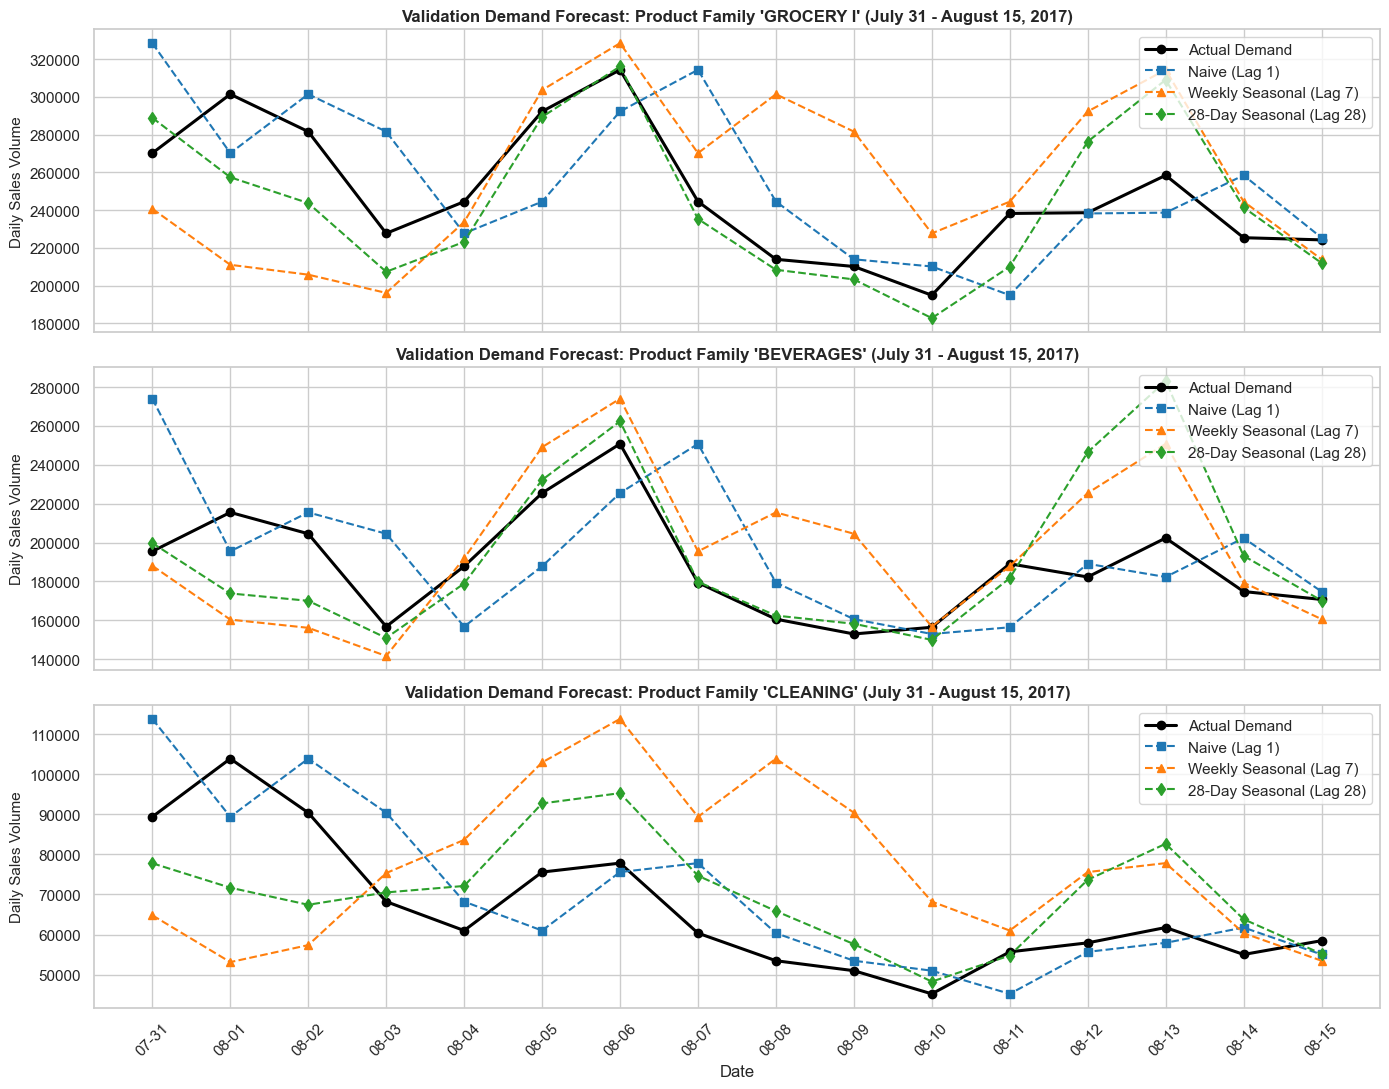

In [8]:
families_to_plot = ["GROCERY I", "BEVERAGES", "CLEANING"]
fig, axes = plt.subplots(len(families_to_plot), 1, figsize=(14, 11), sharex=True)

for i, family_name in enumerate(families_to_plot):
    fam_data = val_split[val_split["family"] == family_name].sort_values("date")
    ax = axes[i]
    ax.plot(fam_data["date"], fam_data["daily_sales"], label="Actual Demand", color="black", linewidth=2.2, marker="o")
    ax.plot(fam_data["date"], fam_data["lag_1"], label="Naive (Lag 1)", color="#1f77b4", linestyle="--", marker="s")
    ax.plot(fam_data["date"], fam_data["lag_7"], label="Weekly Seasonal (Lag 7)", color="#ff7f0e", linestyle="--", marker="^")
    ax.plot(fam_data["date"], fam_data["lag_28"], label="28-Day Seasonal (Lag 28)", color="#2ca02c", linestyle="--", marker="d")
    
    ax.set_title(f"Validation Demand Forecast: Product Family '{family_name}' (July 31 - August 15, 2017)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Daily Sales Volume", fontsize=11)
    ax.legend(loc="upper right", frameon=True)

plt.xlabel("Date", fontsize=12)
plt.xticks(val_split["date"].unique(), [d.strftime('%m-%d') for d in sorted(val_split["date"].unique())], rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, "baseline_predictions.png"), dpi=300)
plt.show()

## 9. Save Feature-Engineered Dataset

In [9]:
output_filepath = os.path.join(outputs_dir, "forecast_features.csv")
df_clean.to_csv(output_filepath, index=False)
print(f"Feature engineered dataset saved to '{output_filepath}' ({os.path.getsize(output_filepath)/(1024*1024):.2f} MB).")

Feature engineered dataset saved to '../outputs\forecast_features.csv' (9.78 MB).


## Feature Engineering & Baseline Findings

### 1. Final Dataset & Feature Summary
- **Final Clean Dataset Size**: 54,648 rows × 29 columns.
- **Number of Product Families**: 33 product families.
- **Number of Engineered Features**: 25 input features (including temporal calendar indicators, interpolated oil prices, date-level holiday flags, lag values, and rolling window means/stds).
- **Training Period**: `2013-01-29` to `2017-07-30` (54,120 rows across 33 families).
- **Validation Period**: `2017-07-31` to `2017-08-15` (528 rows across 33 families, corresponding to the 16-day test window).

### 2. Baseline Model Performance Benchmark

| Model | MAE | RMSE | MAPE (%) |
| :--- | :---: | :---: | :---: |
| **28-Day Seasonal (Lag 28)** | **2,502.52** | **7,727.94** | 24.73% |
| **Naive (Lag 1)** | **3,797.19** | **10,552.48** | 21.66% |
| **Weekly Seasonal (Lag 7)** | **3,868.20** | **11,724.69** | **21.53%** |

### 3. Insights & Baseline Analysis
- **Best Baseline on MAE & RMSE**: The **28-Day Seasonal (Lag 28)** model significantly outperformed Naive (Lag 1) and Weekly Seasonal (Lag 7) baselines on error magnitude, achieving an **MAE of 2,502.52** (a **34% error reduction** compared to Naive).
- **Why 28-Day Lag Performs Best**: In retail sales, customer purchasing behavior aligns closely with monthly pay cycles (15th and end-of-month paydays in Ecuador). A 28-day lag aligns both day-of-week and month-end purchasing patterns.
- **MAPE Characteristics**: While Lag 28 minimizes absolute deviations (MAE/RMSE), Weekly Seasonal (Lag 7) achieves slightly lower percentage error (MAPE: 21.53% vs 24.73%) because Lag 7 performs better on low-volume families where small absolute errors yield higher percentage impacts.

### 4. Limitations of Simple Baselines
- **Ignored External Factors**: Simple lag baselines cannot capture the impact of promotional campaigns (`promotion_count`), oil price shocks, or active holiday events.
- **Inability to Learn Complex Interactions**: Baselines copy historical single-point values without leveraging rolling averages, trend slopes, or cross-family interactions.
- **Next Step**: Future machine learning models (e.g. LightGBM / XGBoost) will build upon these engineered features to surpass the 28-Day Seasonal benchmark.